

# Notebook 



-----------

Before running this notebook, take a look at the _settings.py file. This python script defines paths to data files and directories used in this notebook.
It also defines some configurations, resolutions and options to use when running the script.
Adjust the paths as needed before proceeding with the rest of the notebook.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import sys
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline 


sys.path.append('../..') # location of dem4cli package
from dem4cli import * # to call fxns directly


In [2]:
print(np.__version__)
print(pd.__version__)

1.25.1
2.0.3


In [3]:
# This code can be run using different configurations, different resolutions and different options. Which ones are we using?

flags

{'version': 2,
 'pop_resolution': 0.1,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024',
 'countrymask': 'shapefile'}

In [127]:
country = 'India'
state = 'Rajasthan'

In [128]:
if country == 'India':
    if state == 'India':
        ISO = 'IND'
    elif state == 'Rajasthan':
        ISO = 'IN.RJ'
    elif state == 'Kerala':
        ISO = 'IN.KL'

In [100]:
indicators = ['extreme_drought', 'HI-danger', 'heavy_precipitation_days', 'fwixd']
scenarios = ['NGFS-CurPol', 'NGFS-Net-Zero-2050']

In [27]:
# We'll run the analysis on a domain that can be specified here: Lat S, Lat N, Lon W, Lon E.

bbox_indiaws = [ 2.00, 40.00, 66.00, 100.00 ]
bbox_europe = [ 31.99,  71.09, -14.96,  34.94]
bbox_iberia = [ 36.00, 44.00, -10.00, 5.00]

## Population preprocessing, plot life expectancy

This section take care of loading and preprocessing all demographic data required for the analysis. 
It uses a wrapper function called preprocess_all_country_data and defined in population_demographics.py.

You can have a look at how preprocess_all_country_data is defined to understand which functions it calls and what it does. 
You can also read the Methods part of Grant et al. (2025) or the Supplementary Material of Thiery et al. (2021) to understand what demographic data are used in this analysis and how they are processed for this purpose.

In [6]:
# Indicate the geographic domain to look at by specifying the argument bbox

d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    ssp=2,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = bbox_indiaws,

    filepath_countrymask = filepath_countrymask,
    data_source_countrymask = 'shapefile',
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_world_bank = filepath_world_bank_meta, # metadata 
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )

df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] 
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
countries_regions, countries_mask = d_countries['mask']

load_country_metadata took 0.87 s
load_unwpp_lifeexpectancy took 22.95 s
get_life_expectancies took 0.00 s
loading cohort sizes from UNWPP2024
load_cohort_sizes took 22.89 s
interpolate_cohortsize_countries took 0.01 s
opening compass - historical
opening compass - ssp2
load_population took 2.93 s
load_countrymask took 1.87 s
preprocess_all_country_data took 51.56 s


In [7]:
df_life_expectancy_5

Country,Afghanistan,Bangladesh,Bhutan,China,India,Indonesia,Kyrgyzstan,Malaysia,Maldives,Myanmar,Nepal,Pakistan,Sri Lanka,Tajikistan,Thailand,Turkmenistan,Uzbekistan
Year,,,,,,,,,,,,,,,,,
1950,54.7051,64.3785,57.9877,63.3719,64.9698,64.4966,69.7542,66.4392,63.9401,62.6148,62.5044,62.6678,70.9775,70.2939,64.0547,68.1564,71.5994
1951,54.9914,64.5367,58.0507,63.7418,65.1229,64.8597,69.93,66.9031,63.8358,62.9,62.4709,63.1308,71.3957,70.4403,64.265,68.3596,71.7428
1952,55.3287,65.1587,58.1325,64.1075,65.192,65.2115,70.0851,67.3864,63.7576,63.2916,62.495,63.5415,71.7427,70.6044,64.4666,68.545,71.891
1953,55.6465,65.3259,58.2343,64.3401,65.3613,65.232,70.2454,67.9438,63.7143,63.649,62.5481,63.9462,72.1706,70.7993,64.6241,68.7415,72.0515
1954,55.9651,65.6375,58.3607,59.6083,65.6637,65.7349,70.4077,68.507,63.6957,63.8958,62.719,64.333,72.5638,71.0318,64.9301,68.9108,72.2161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,76.3344,82.9225,81.2563,85.5551,80.6474,78.9437,79.1021,83.6094,88.1359,76.2366,78.775,78.0595,84.4865,79.9808,83.8029,78.91,79.8067
2022,76.441,83.1252,81.4446,85.748,80.8202,79.0574,79.211,83.7631,88.3445,76.3769,78.9434,78.1174,84.6453,80.0795,83.9901,78.9788,79.9032
2023,76.5566,83.3198,81.6378,85.9295,80.9699,79.1701,79.3258,83.9184,88.5411,76.5151,79.1097,78.1822,84.8139,80.1706,84.1884,79.0452,80.0172


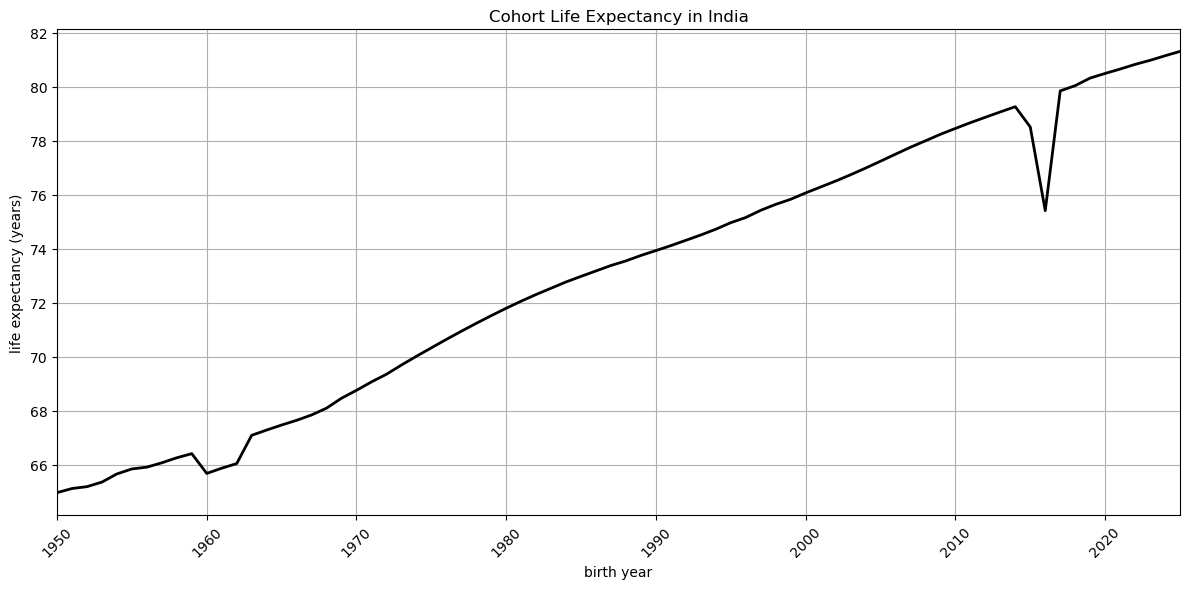

In [28]:
# Extract life expectancy data for the country of interest
life_expectancy_country = df_life_expectancy_5[country]

# Create a plot
plt.figure(figsize=(12, 6))

# Plot the life expectancy over the years
plt.plot(life_expectancy_country.index, life_expectancy_country.values,
         color='black', linewidth=2)

# Customize the plot
plt.title(f'Cohort Life Expectancy in {country}')
plt.xlabel('birth year')
plt.ylabel('life expectancy (years)')
plt.grid(True)
plt.xticks(ticks=range(life_expectancy_country.index.min(), life_expectancy_country.index.max() + 1, 10),
           rotation=45)
plt.xlim(life_expectancy_country.index.min(), life_expectancy_country.index.max())

# Show the plot
plt.tight_layout()
plt.show()

## Load area-weighted averages from RIME-X and plot results

In [129]:
# Load results from RIME-X

scenario_names = [scen_name.replace(' ','-') for scen_name in scenarios]
scen_names_stitched = '_'.join(scenario_names)
ind_stitched = '_'.join(indicators)
ISO = ISO.replace('.','-')

path_csvfile = f'/data/brussel/vo/000/bvo00012/vsc11359/data_rime-x/{scen_names_stitched}_{ind_stitched}_{ISO}_pop.csv'
path_csvfile

'/data/brussel/vo/000/bvo00012/vsc11359/data_rime-x/NGFS-CurPol_NGFS-Net-Zero-2050_extreme_drought_HI-danger_heavy_precipitation_days_fwixd_IN-RJ_pop.csv'

In [130]:
df_ts_quantiles = pd.read_csv(path_csvfile)
df_ts_quantiles

,quantile,year,extreme_drought,extreme_drought.1,HI-danger,HI-danger.1,heavy_precipitation_days,heavy_precipitation_days.1,fwixd,fwixd.1
0,NaN,NaN,NGFS CurPol,NGFS Net-Zero 2050,NGFS CurPol,NGFS Net-Zero 2050,NGFS CurPol,NGFS Net-Zero 2050,NGFS CurPol,NGFS Net-Zero 2050
1,0.50,1950.0,10.447316095448627,10.447316095448627,71.41225163206082,71.41225163206082,15.635510087385265,15.635510087385265,17.636453714162826,17.636453714162826
2,0.50,1951.0,10.447316095448627,10.447316095448627,71.41225163206082,71.41225163206082,15.635510087385265,15.635510087385265,17.636453714162826,17.636453714162826
3,0.50,1952.0,10.447316095448627,10.447316095448627,71.41225163206082,71.41225163206082,15.635510087385265,15.635510087385265,17.636453714162826,17.636453714162826
4,0.50,1953.0,10.447316095448627,10.447316095448627,71.41225163206082,71.41225163206082,15.635510087385265,15.635510087385265,17.636453714162826,17.636453714162826
...,...,...,...,...,...,...,...,...,...,...
1053,0.95,2096.0,98.20947371619766,53.671300667760065,177.43465310560777,102.21554500110707,27.26844314752283,22.296222254143274,30.75564556058512,25.01696626652599
1054,0.95,2097.0,98.22412036180359,53.30746414801788,178.11260881830415,101.88650895944772,27.267057441135567,22.247369902518894,30.828937510743692,24.954126005046195
1055,0.95,2098.0,98.24795372958542,52.959660328267944,178.78166675007597,101.59035768430182,27.245833858082815,22.17713955292304,30.97483162833203,24.932559708342158
1056,0.95,2099.0,98.26412865663924,52.76545283375081,179.60983405008966,101.49690451053276,27.26183466085482,22.16740357383114,31.166071232460922,24.876793075899382


In [131]:
# Exporting from RIME-X into a .csv file messed up the format
# Manually fix that (for now)

columns = [
    (                'quantile',                   ''),
    (                    'year',                   ''),
    (         'extreme_drought',        'NGFS CurPol'),
    (         'extreme_drought', 'NGFS Net-Zero 2050'),
    (               'HI-danger',        'NGFS CurPol'),
    (               'HI-danger', 'NGFS Net-Zero 2050'),
    ('heavy_precipitation_days',        'NGFS CurPol'),
    ('heavy_precipitation_days', 'NGFS Net-Zero 2050'),
    (                   'fwixd',        'NGFS CurPol'),
    (                   'fwixd', 'NGFS Net-Zero 2050')
]
df_ts_quantiles.columns = pd.MultiIndex.from_tuples(columns)

In [132]:
df_ts_quantiles

quantile    year     extreme_drought                      \
                              NGFS CurPol  NGFS Net-Zero 2050   
0         NaN     NaN         NGFS CurPol  NGFS Net-Zero 2050   
1        0.50  1950.0  10.447316095448627  10.447316095448627   
2        0.50  1951.0  10.447316095448627  10.447316095448627   
3        0.50  1952.0  10.447316095448627  10.447316095448627   
4        0.50  1953.0  10.447316095448627  10.447316095448627   
...       ...     ...                 ...                 ...   
1053     0.95  2096.0   98.20947371619766  53.671300667760065   
1054     0.95  2097.0   98.22412036180359   53.30746414801788   
1055     0.95  2098.0   98.24795372958542  52.959660328267944   
1056     0.95  2099.0   98.26412865663924   52.76545283375081   
1057     0.95  2100.0   98.26412865663927   52.67497101491843   

               HI-danger                     heavy_precipitation_days  \
             NGFS CurPol  NGFS Net-Zero 2050              NGFS CurPol   
0            NGFS CurPol  NGFS Net-Zero 2050              NGFS CurPol   
1      71.41225163206082   71.41225163206082       15.635510087385265   
2      71.41225163206082   71.41225163206082       15.635510087385265   
3      71.41225163206082   71.41225163206082       15.635510087385265   
4      71.41225163206082   71.41225163206082       15.635510087385265   
...                  ...                 ...                      ...   
1053  177.43465310560777  102.21554500110707        27.26844314752283   
1054  178.11260881830415  101.88650895944772       27.267057441135567   
1055  178.78166675007597  101.59035768430182       27.245833858082815   
1056  179.60983405008966  101.49690451053276        27.26183466085482   
1057  180.23745672476502  101.49225509178385       27.278840792226344   

                                       fwixd                      
      NGFS Net-Zero 2050         NGFS CurPol  NGFS Net-Zero 2050  
0     NGFS Net-Zero 2050         NGFS CurPol  NGFS Net-Zero 2050  
1     15.635510087385265  17.636453714162826  17.636453714162826  
2     15.635510087385265  17.636453714162826  17.636453714162826  
3     15.635510087385265  17.636453714162826  17.636453714162826  
4     15.635510087385265  17.636453714162826  17.636453714162826  
...                  ...                 ...                 ...  
1053  22.296222254143274   30.75564556058512   25.01696626652599  
1054  22.247369902518894  30.828937510743692  24.954126005046195  
1055   22.17713955292304   30.97483162833203  24.932559708342158  
1056   22.16740357383114  31.166071232460922  24.876793075899382  
1057  22.160619707773467  31.322913392486996  24.854718072116576  

[1058 rows x 10 columns]

In [133]:
print(df_ts_quantiles.columns)
print(df_ts_quantiles.index)
print(df_ts_quantiles.columns.get_level_values(0).unique())
print(df_ts_quantiles['quantile'].unique())

MultiIndex([(                'quantile',                   ''),
            (                    'year',                   ''),
            (         'extreme_drought',        'NGFS CurPol'),
            (         'extreme_drought', 'NGFS Net-Zero 2050'),
            (               'HI-danger',        'NGFS CurPol'),
            (               'HI-danger', 'NGFS Net-Zero 2050'),
            ('heavy_precipitation_days',        'NGFS CurPol'),
            ('heavy_precipitation_days', 'NGFS Net-Zero 2050'),
            (                   'fwixd',        'NGFS CurPol'),
            (                   'fwixd', 'NGFS Net-Zero 2050')],
           )
RangeIndex(start=0, stop=1058, step=1)
Index(['quantile', 'year', 'extreme_drought', 'HI-danger',
       'heavy_precipitation_days', 'fwixd'],
      dtype='object')
[ nan 0.5  0.05 0.1  0.25 0.75 0.9  0.95]


In [134]:
## Process dataframe for easier manipulation and plotting
# Ensure 'year' is numeric (if it's a string, convert it)
df_ts_quantiles = df_ts_quantiles.apply(pd.to_numeric, errors='coerce')

# Sort the DataFrame by 'year' for efficient filtering
df_ts_quantiles = df_ts_quantiles.sort_values('year')

# Melt the DataFrame to long format for easier plotting
df_ts_quantiles_melted = df_ts_quantiles.melt(
    id_vars=[
        ('quantile', ''),  # Preserve the quantile column
        ('year', '')       # Preserve the year column
    ],
    value_vars=[
        ('extreme_drought', 'NGFS CurPol'),
        ('extreme_drought', 'NGFS Net-Zero 2050'),
        ('HI-danger', 'NGFS CurPol'),
        ('HI-danger', 'NGFS Net-Zero 2050'),
        ('heavy_precipitation_days', 'NGFS CurPol'),
        ('heavy_precipitation_days', 'NGFS Net-Zero 2050'),
        ('fwixd', 'NGFS CurPol'),
        ('fwixd', 'NGFS Net-Zero 2050')
    ],
    var_name=['indicator', 'scenario'],
    value_name='value'
)

# Rename the 'year' column for clarity
df_ts_quantiles_melted.rename(columns={('year', ''): 'year', ('quantile', ''): 'quantile'}, inplace=True)

In [135]:
df_ts_quantiles_melted

,quantile,year,indicator,scenario,value
0,0.75,1950.0,extreme_drought,NGFS CurPol,17.028365
1,0.10,1950.0,extreme_drought,NGFS CurPol,4.334444
2,0.90,1950.0,extreme_drought,NGFS CurPol,26.801637
3,0.05,1950.0,extreme_drought,NGFS CurPol,3.316324
4,0.25,1950.0,extreme_drought,NGFS CurPol,7.401994
...,...,...,...,...,...
8459,0.50,2100.0,fwixd,NGFS Net-Zero 2050,19.623887
8460,0.75,2100.0,fwixd,NGFS Net-Zero 2050,22.009237
8461,0.05,2100.0,fwixd,NGFS Net-Zero 2050,14.577519
8462,0.95,2100.0,fwixd,NGFS Net-Zero 2050,24.854718


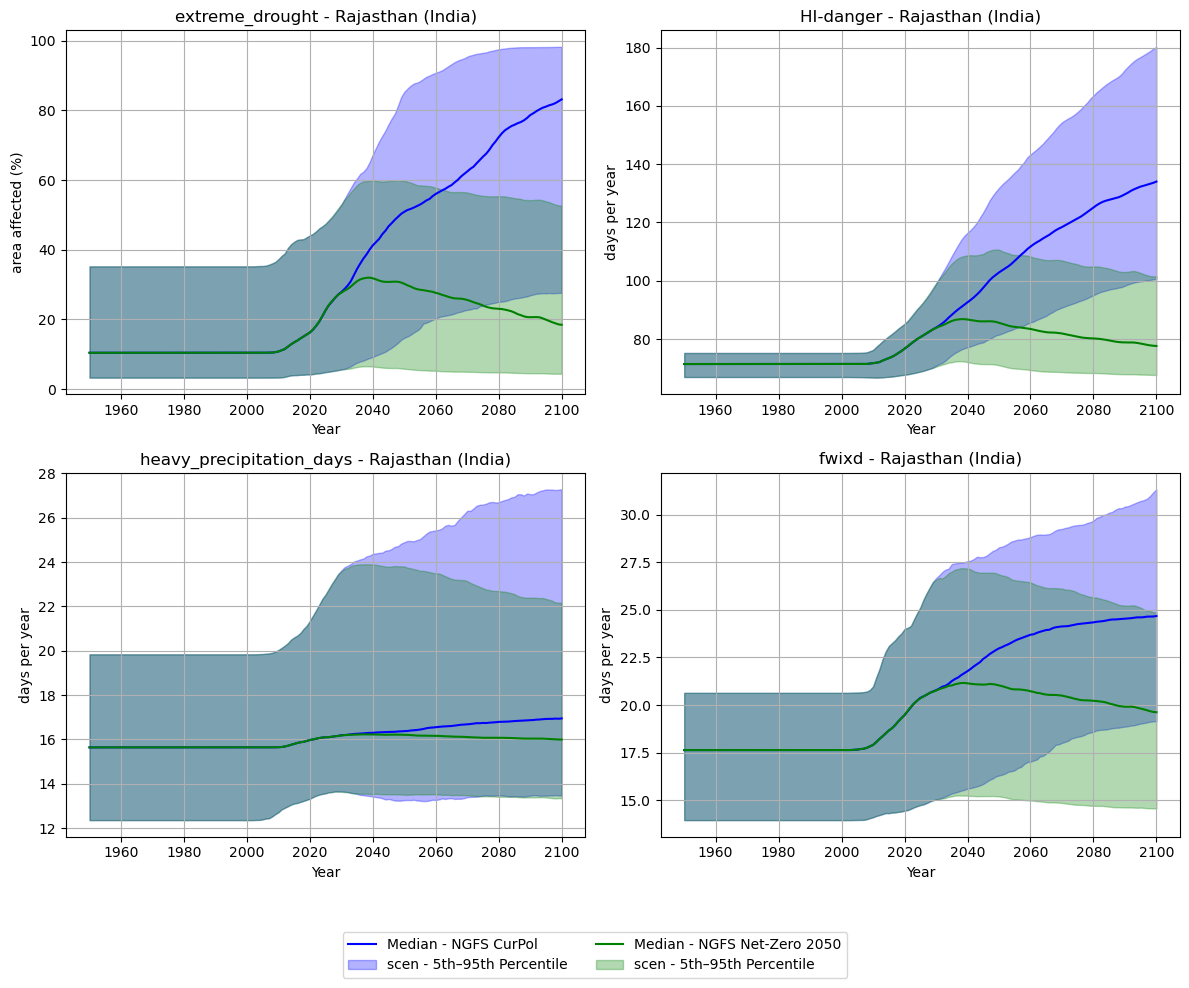

In [136]:
colors = ['blue', 'green']
tick_interval = 20 # set interval for x axis tick for plotting

# Quantiles for plotting
low_quantile = 0.05
high_quantile = 1 - low_quantile

# Get unique indicators
indicator_list = df_ts_quantiles_melted['indicator'].unique()
scenario_list = df_ts_quantiles_melted['scenario'].unique()

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
axs = axs.flatten() if len(indicator_list) > 1 else [axs]

for ind_index, ind in enumerate(indicator_list):

 # Filter data for the current indicator
    indicator_data = df_ts_quantiles_melted[df_ts_quantiles_melted['indicator'] == ind]

    # Loop through each scenario
    for scen_index, scen in enumerate(scenario_list):
        # Filter data for the current scenario
        scen_data = indicator_data[indicator_data['scenario'] == scen]

        # Plot results
        axs[ind_index].plot(scen_data[scen_data['quantile'] == 0.5]['year'], scen_data[scen_data['quantile'] == 0.5]['value'], label=f'Median - {scen}', color=colors[scen_index])
        axs[ind_index].fill_between(scen_data[scen_data['quantile'] == 0.5]['year'], scen_data[scen_data['quantile'] == low_quantile]['value'], scen_data[scen_data['quantile'] == high_quantile]['value'], 
                         color=colors[scen_index], alpha=0.3, label=f'scen - {int(low_quantile*100)}th–{int(high_quantile*100)}th Percentile')

     # Set labels, titles and grid
    axs[ind_index].set_xlabel('Year')
    
    if ind in ['HI-caution', 'HI-danger', 'fwixd', 'heavy_precipitation_days']:
        axs[ind_index].set_ylabel('days per year')
    elif ind in ['extreme_drought']:
        axs[ind_index].set_ylabel('area affected (%)')

    if country == state:
        axs[ind_index].set_title(f'{ind} - {country}')
    else:
        axs[ind_index].set_title(f'{ind} - {state} ({country})')
    axs[ind_index].grid(True)
    axs[ind_index].xaxis.set_major_locator(MultipleLocator(tick_interval))

# Add a column legend
handles, labels = axs[ind_index].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.1))

plt.tight_layout()
plt.show()

## Calculate lifetime exposure with a function and plot results



In [137]:
ds_lifetime_exp = calc_lifetime_exposure_rimex(df_life_expectancy_5, 1950, 2010, df_ts_quantiles, country=country)

2100.0
calc_lifetime_exposure_rimex took 0.03 s


In [138]:
ds_lifetime_exp

<xarray.Dataset>
Dimensions:                   (birth_year: 61, quantile: 7, scenario: 2)
Coordinates:
  * birth_year                (birth_year) int64 1950 1951 1952 ... 2009 2010
  * quantile                  (quantile) float64 0.05 0.1 0.25 0.5 0.75 0.9 0.95
  * scenario                  (scenario) object 'NGFS CurPol' 'NGFS Net-Zero ...
Data variables:
    HI-danger                 (birth_year, quantile, scenario) object 4349.09...
    extreme_drought           (birth_year, quantile, scenario) object 216.862...
    fwixd                     (birth_year, quantile, scenario) object 908.548...
    heavy_precipitation_days  (birth_year, quantile, scenario) object 805.966...

In [139]:
# Convert lifetime exposure from cumulated days to cumulated years
ds_lifetime_exp_toplot = ds_lifetime_exp / 365.25

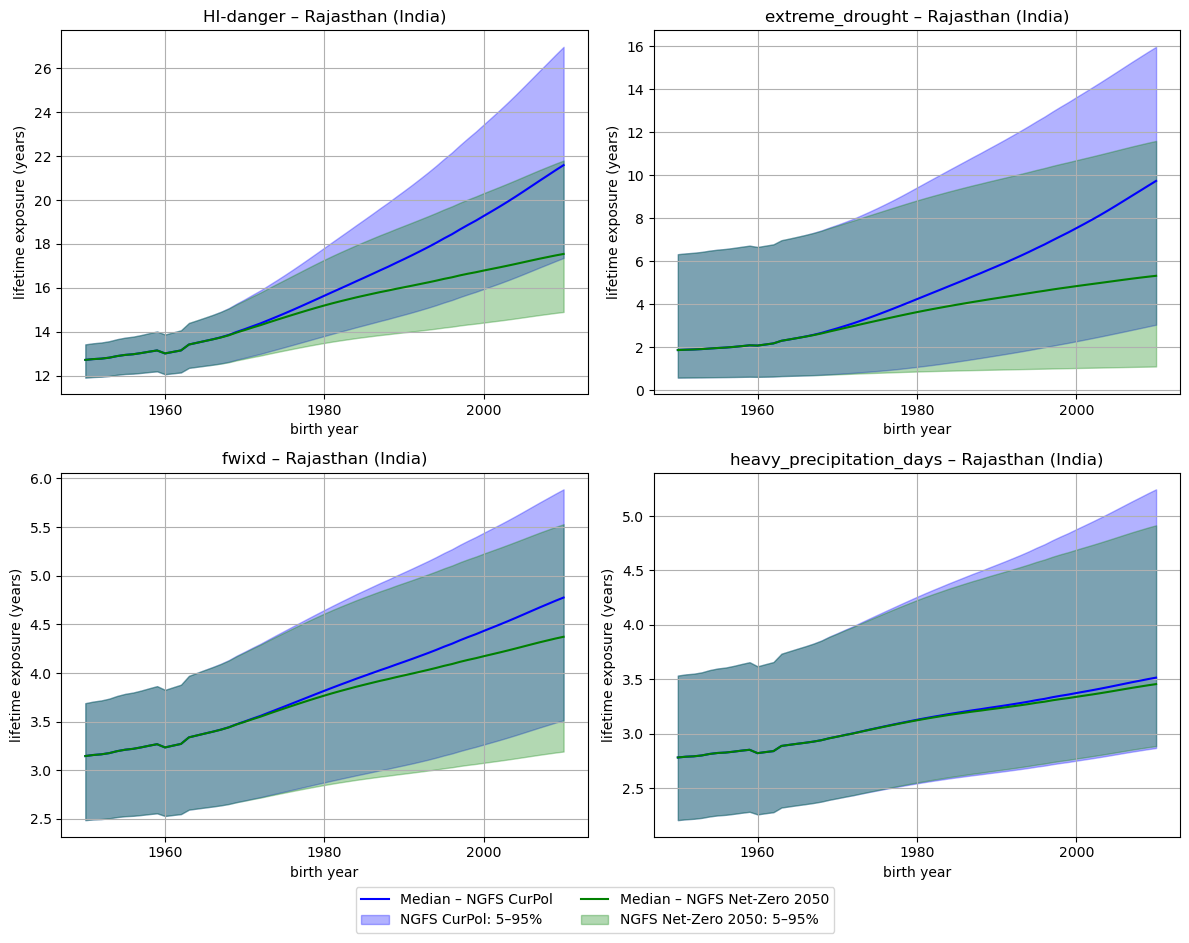

In [140]:
colors = ['blue', 'green']
tick_interval = 20

low_q = 0.05
mid_q = 0.5
high_q = 0.95

scenario_list = ds_lifetime_exp_toplot.scenario.values
indicator_list = list(ds_lifetime_exp_toplot.data_vars)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
axs = axs.flatten() if len(indicators) > 1 else [axs]

for ind_idx, ind in enumerate(indicator_list):
    da = ds_lifetime_exp_toplot[ind]

    for scen_idx, scen in enumerate(scenario_list):

        # Select quantiles
        median = da.sel(scenario=scen, quantile=mid_q).values
        low = da.sel(scenario=scen, quantile=low_q).values
        high = da.sel(scenario=scen, quantile=high_q).values
        birth_years = da.birth_year.values

        # Convert to float64 arrays
        median = np.array(median, dtype=np.float64)
        low = np.array(low, dtype=np.float64)
        high = np.array(high, dtype=np.float64)

        # Plot median
        axs[ind_idx].plot(
            birth_years,
            median,
            color=colors[scen_idx],
            label=f'Median – {scen}'
        )

        # Fill uncertainty range
        axs[ind_idx].fill_between(
            birth_years,
            low,
            high,
            color=colors[scen_idx],
            alpha=0.3,
            label=f'{scen}: {int(low_q*100)}–{int(high_q*100)}%'
        )

    # Axis styling
    if country == state:
        axs[ind_idx].set_title(f'{ind} – {country}')
    else:
        axs[ind_idx].set_title(f'{ind} – {state} ({country})')
    axs[ind_idx].set_xlabel('birth year')
    axs[ind_idx].set_ylabel('lifetime exposure (years)')
    axs[ind_idx].grid(True)
    axs[ind_idx].xaxis.set_major_locator(MultipleLocator(tick_interval))

# Shared legend (column legend)
handles, labels = axs[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.show()

# OLD: Calculate lifetime exposure by manipulating the dataframe and convert to dataset only at the end

In [20]:
def calc_lifetime_exposure_rimex_df(df_life_expectancy, start_birthyear, end_birthyear, df_ts_quantiles, country='Portugal'):

    # 1. Get all columns except 'quantile' and 'year'
    columns_to_process = [ 
        col for col in df_ts_quantiles.columns
        if col[0] not in ['quantile', 'year']
    ]


    # 2. Determine maximum death year and maximum year currently in the dataframe
    death_years = []
    for birth_yr in range(start_birthyear, end_birthyear + 1):
        life_expectancy = df_life_expectancy.loc[birth_yr, country]
        death_yr = birth_yr + life_expectancy
        death_years.append(death_yr)
    max_death_yr = int(np.floor(max(death_years)))
    current_max_year = df_ts_quantiles[('year', '')].max()  
    

    # 3. If needed, extend the data up until the maximum death year by adding the mean of the last 10 years
    # for all quantiles and columns  
    min_year = int(df_ts_quantiles[('year', '')].min())
    if max_death_yr > current_max_year:

        extended_data_dfs = []

        for quantile in df_ts_quantiles['quantile'].dropna().unique():

            quantile_mask = (df_ts_quantiles['quantile'] == quantile)
            quantile_data = df_ts_quantiles.loc[quantile_mask].copy()

            # Set 'year' as the index for reindexing later
            quantile_data = quantile_data.set_index(('year', ''))

            # Create a new DataFrame with an extended time index 
            extended_index = range(min_year, max_death_yr + 1)
            extended_quantile_data = pd.DataFrame(index=extended_index)

            # Copy the 'year' and 'quantile' columns
            extended_quantile_data[('year', '')] = extended_index
            extended_quantile_data[('quantile', '')] = quantile

            for col in columns_to_process:
                last_10_years_mean = quantile_data[col].iloc[-10:].mean()
                extended_quantile_data[col] = quantile_data[col].reindex(
                    extended_index, fill_value=last_10_years_mean
                )
            
            # Append the extended data to the list
            extended_data_dfs.append(extended_quantile_data)

        # Combine the extended data for all quantiles and rename the 'year' and 'quantile' columns
        df_ts_quantiles = pd.concat(extended_data_dfs)
        df_ts_quantiles.rename(columns={('year', ''): 'year', ('quantile', ''): 'quantile'}, inplace=True)


    # 4. Loop over all birth years to calculate integral over lifetime for each cohort
    d_lifetime_exp = {} 

    for birth_yr in range(start_birthyear, end_birthyear+1):
        
        # Get life expectancy for that specified country and calculate death year
        life_expectancy = df_life_expectancy.loc[birth_yr, country]
        death_yr = birth_yr + np.floor(life_expectancy)

        # Filter for years lived fully, group by quantiles and sum over them
        fullyears_df = df_ts_quantiles[(df_ts_quantiles['year'] >= birth_yr) & (df_ts_quantiles['year'] <= death_yr-1)]
        summed_df = fullyears_df.groupby('quantile').sum()

        # Filter for year lived partially, group by quantiles and multiply the exposure for that year by the fraction of year lived
        # Then add it to summed_df
        partialyear_df = df_ts_quantiles[(df_ts_quantiles['year'] == death_yr)]
        partialexposure_df = partialyear_df.groupby('quantile').sum() * (life_expectancy - np.floor(life_expectancy))
        summed_df = summed_df + partialexposure_df

        # Store the result for this birth year
        summed_df = summed_df.drop(columns=['year'], errors='ignore')
        d_lifetime_exp[birth_yr] = summed_df
    

    # 5. Manipulate the DataFrame before storing into an xarray dataset 
    # Combine dictionary into one big DataFrame 
    df_concat = pd.concat(d_lifetime_exp, names=["birth year", "quantile"]) 

    # Ensure column MultiIndex is named correctly 
    df_concat.columns = pd.MultiIndex.from_tuples(df_concat.columns, names=["indicator", "scenario"] )

    # Convert to xarray: indicator becomes variables, scenario becomes dimension 
    ds_lifetime_exp = df_concat.stack(level="scenario").to_xarray() 
    
    # Rename this dimension 
    ds_lifetime_exp = ds_lifetime_exp.rename({"birth year": "birth_year"})

    return ds_lifetime_exp

# OLD: Calculate lifetime exposure without a function and plot results

In [21]:
# Compute sum over lifetime

start_birthyear = 1950
end_birthyear = 2000

## Initialize a dictionary to store results for each starting year
d_lifetime_exp = {}

# Iterate over each birth year (for each birth cohort)
for birth_yr in range(start_birthyear, end_birthyear+1):

    # Get life expectancy
    life_expectancy = df_life_expectancy_5.loc[birth_yr, 'Portugal']

    # Define death year based on life expectancy
    death_yr = birth_yr + np.floor(life_expectancy)

    # Filter for years lived fully, group by quantiles and sum over them
    fullyears_df = df_ts_quantiles[(df_ts_quantiles['year'] >= birth_yr) & (df_ts_quantiles['year'] <= death_yr-1)]
    summed_df = fullyears_df.groupby('quantile').sum()

    # Filter for year lived partially, group by quantiles and multiply the exposure for that year by the fraction of year lived
    partialyear_df = df_ts_quantiles[(df_ts_quantiles['year'] == death_yr)]
    partialexposure_df = partialyear_df.groupby('quantile').sum() * (life_expectancy - np.floor(life_expectancy))

    # Add the partial exposure to summed_df
    summed_df = summed_df + partialexposure_df

    # Store the result for this starting year
    summed_df = summed_df.drop(columns=['year'], errors='ignore')
    d_lifetime_exp[birth_yr] = summed_df

# Combine all results into a single DataFrame (optional)
df_lifetime_exp = pd.concat(d_lifetime_exp, names=['birth year', 'quantile'])

KeyError: 'Portugal'

In [ ]:
# Process the dataframe with lifetime exposure results for plotting 

# Convert from cumulated days to cumulated years
df_lifetime_exp_years = df_lifetime_exp / 365.25

# Reset the index to convert 'birth year' and 'quantile' into columns
df_lifetime_exp_reset = df_lifetime_exp_years.reset_index()

# Melt the DataFrame to long format
df_lifetime_exp_melted = df_lifetime_exp_reset.melt(
    id_vars=['birth year', 'quantile'],
    var_name=['indicator', 'scenario'],
    value_name='value'
)



In [ ]:
df_lifetime_exp

fwixd                      HI-caution  \
                     NGFS CurPol NGFS Net-Zero 2050  NGFS CurPol   
birth year quantile                                                
1950       0.05      1069.698380        1069.722955  5366.258601   
           0.10      1090.338046        1090.415132  5524.563062   
           0.25      1257.718873        1257.757017  5617.184631   
           0.50      1524.701606        1524.822258  5727.514284   
           0.75      1728.550379        1728.758131  5817.750180   
...                          ...                ...          ...   
2000       0.25      2292.985414        1831.335952  7287.508443   
           0.50      2738.478131        2226.862369  7606.837195   
           0.75      3098.439669        2604.965912  7915.654732   
           0.90      3430.347078        2943.551304  8279.200834   
           0.95      3618.169436        3175.561523  8510.683046   

                                        
                    NGFS Net-Zero 2050  
birth year quantile                     
1950       0.05            5366.253162  
           0.10            5524.623377  
           0.25            5617.267128  
           0.50            5727.635007  
           0.75            5817.971681  
...                                ...  
2000       0.25            6607.268523  
           0.50            6894.276553  
           0.75            7232.917984  
           0.90            7581.560998  
           0.95            7816.148761  

[357 rows x 4 columns]

In [ ]:
print(df_lifetime_exp.columns)
print(df_lifetime_exp.index)

MultiIndex([(     'fwixd',        'NGFS CurPol'),
            (     'fwixd', 'NGFS Net-Zero 2050'),
            ('HI-caution',        'NGFS CurPol'),
            ('HI-caution', 'NGFS Net-Zero 2050')],
           )
MultiIndex([(1950, 0.05),
            (1950,  0.1),
            (1950, 0.25),
            (1950,  0.5),
            (1950, 0.75),
            (1950,  0.9),
            (1950, 0.95),
            (1951, 0.05),
            (1951,  0.1),
            (1951, 0.25),
            ...
            (1999, 0.75),
            (1999,  0.9),
            (1999, 0.95),
            (2000, 0.05),
            (2000,  0.1),
            (2000, 0.25),
            (2000,  0.5),
            (2000, 0.75),
            (2000,  0.9),
            (2000, 0.95)],
           names=['birth year', 'quantile'], length=357)


In [ ]:
df_lifetime_exp_melted

,birth year,quantile,indicator,scenario,value
0,1950,0.05,fwixd,NGFS CurPol,2.928675
1,1950,0.10,fwixd,NGFS CurPol,2.985183
2,1950,0.25,fwixd,NGFS CurPol,3.443447
3,1950,0.50,fwixd,NGFS CurPol,4.174405
4,1950,0.75,fwixd,NGFS CurPol,4.732513
...,...,...,...,...,...
1423,2000,0.25,HI-caution,NGFS Net-Zero 2050,18.089715
1424,2000,0.50,HI-caution,NGFS Net-Zero 2050,18.875500
1425,2000,0.75,HI-caution,NGFS Net-Zero 2050,19.802650
1426,2000,0.90,HI-caution,NGFS Net-Zero 2050,20.757183


In [ ]:
print(df_lifetime_exp_melted.columns)
print(df_lifetime_exp_melted.index)

Index(['birth year', 'quantile', 'indicator', 'scenario', 'value'], dtype='object')
RangeIndex(start=0, stop=1428, step=1)


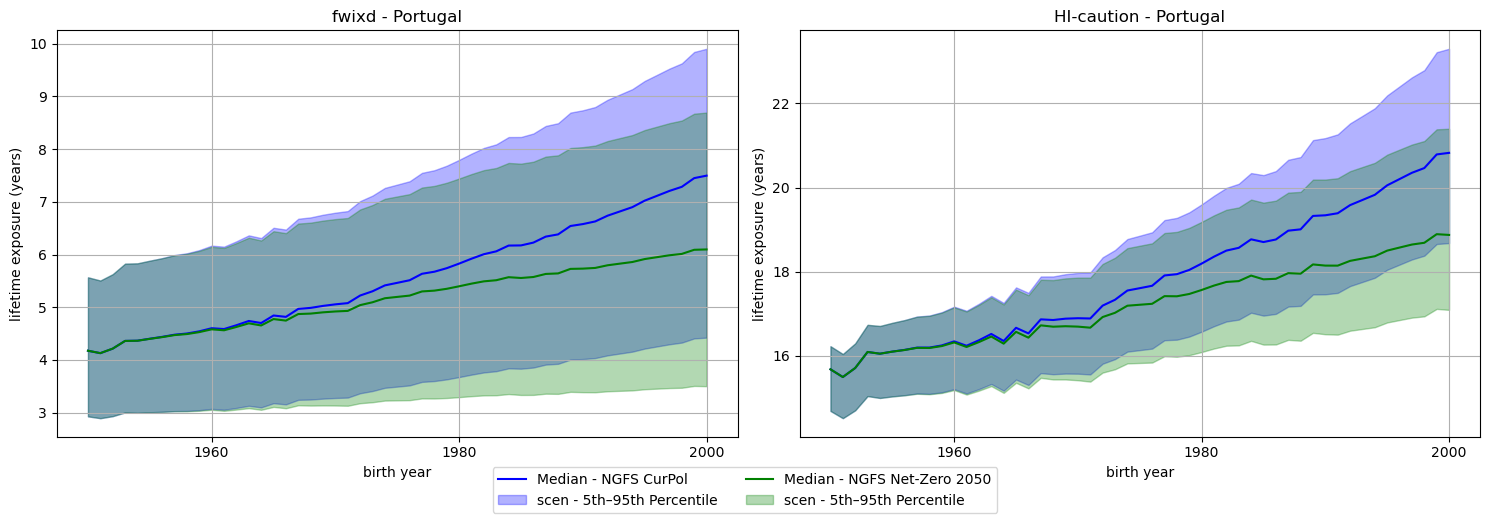

In [ ]:
# Plot the lifetime exposure

colors = ['blue', 'green']
tick_interval = 20 # set interval for x axis tick for plotting

# Quantiles for plotting
low_quantile = 0.05
high_quantile = 1 - low_quantile

# Get unique indicators
indicators = df_ts_quantiles_melted['indicator'].unique()
scenarios = df_ts_quantiles_melted['scenario'].unique()

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
axs = axs.flatten() if len(indicators) > 1 else [axs]

for ind_index, ind in enumerate(indicators):

 # Filter data for the current indicator
    indicator_data = df_lifetime_exp_melted[df_lifetime_exp_melted['indicator'] == ind]

    # Loop through each scenario
    for scen_index, scen in enumerate(scenarios):
        # Filter data for the current scenario
        scen_data = indicator_data[indicator_data['scenario'] == scen]

        # Plot the median 
        axs[ind_index].plot(
            scen_data[scen_data['quantile'] == 0.5]['birth year'], 
            scen_data[scen_data['quantile'] == 0.5]['value'], 
            label=f'Median - {scen}', 
            color=colors[scen_index]
            )

        # Plot the uncertainty range            
        axs[ind_index].fill_between(
            scen_data[scen_data['quantile'] == 0.5]['birth year'], 
            scen_data[scen_data['quantile'] == low_quantile]['value'], 
            scen_data[scen_data['quantile'] == high_quantile]['value'], 
            color=colors[scen_index], 
            alpha=0.3, 
            label=f'scen - {int(low_quantile*100)}th–{int(high_quantile*100)}th Percentile')

     # Set labels, titles and grid
    axs[ind_index].set_xlabel('birth year')
    axs[ind_index].set_ylabel('lifetime exposure (years)')
    axs[ind_index].set_title(f'{ind} - Portugal')
    axs[ind_index].grid(True)
    axs[ind_index].xaxis.set_major_locator(MultipleLocator(tick_interval))

# Add a column legend
handles, labels = axs[ind_index].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()